In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Sales Data.csv to Online Sales Data.csv


In [ ]:
# Upload your CSV file
from google.colab import files
import pandas as pd

uploaded = files.upload()  # click button, select your CSV

# Load it
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving Online Sales Data.csv to Online Sales Data (1).csv
Shape: (240, 9)

First 5 rows:


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,01-01-2024,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,02-01-2024,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,03-01-2024,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,04-01-2024,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,05-01-2024,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
# See all column names and data types
print("Columns & Data Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Columns & Data Types:
Transaction ID        int64
Date                 object
Product Category     object
Product Name         object
Units Sold            int64
Unit Price          float64
Total Revenue       float64
Region               object
Payment Method       object
dtype: object

Basic Statistics:


,Transaction ID,Units Sold,Unit Price,Total Revenue
count,240.00000,240.000000,240.000000,240.000000
mean,10120.50000,2.158333,236.395583,335.699375
std,69.42622,1.322454,429.446695,485.804469
min,10001.00000,1.000000,6.500000,6.500000
25%,10060.75000,1.000000,29.500000,62.965000
50%,10120.50000,2.000000,89.990000,179.970000
75%,10180.25000,3.000000,249.990000,399.225000
max,10240.00000,10.000000,3899.990000,3899.990000


In [ ]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Total duplicates:", df.duplicated().sum())

print("\n=== UNIQUE VALUES IN KEY COLUMNS ===")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

=== MISSING VALUES ===
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

=== DUPLICATE ROWS ===
Total duplicates: 0

=== UNIQUE VALUES IN KEY COLUMNS ===
Date: ['01-01-2024' '02-01-2024' '03-01-2024' '04-01-2024' '05-01-2024'
 '06-01-2024' '07-01-2024' '08-01-2024' '09-01-2024' '10-01-2024'
 '11-01-2024' '12-01-2024' '13-01-2024' '14-01-2024' '15-01-2024'
 '16-01-2024' '17-01-2024' '18-01-2024' '19-01-2024' '20-01-2024'
 '21-01-2024' '22-01-2024' '23-01-2024' '24-01-2024' '25-01-2024'
 '26-01-2024' '27-01-2024' '28-01-2024' '29-01-2024' '30-01-2024'
 '31-01-2024' '01-02-2024' '02-02-2024' '03-02-2024' '04-02-2024'
 '05-02-2024' '06-02-2024' '07-02-2024' '08-02-2024' '09-02-2024'
 '10-02-2024' '11-02-2024' '12-02-2024' '13-02-2024' '14-02-2024'
 '15-02-2024' '16-02-2024' '17-02-2024' '18-02-2024' '19-02-2024'
 '20-02-2024' '21-

In [ ]:
# Keep a copy of original first
df_original = df.copy()

# Fill missing numbers with median
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled {col} nulls with median: {median_val}")

# Fill missing text with 'Unknown'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)
        print(f"Filled {col} nulls with 'Unknown'")

print("\nMissing values after fix:")
print(df.isnull().sum())


Missing values after fix:
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64


In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after} duplicate rows")
print(f"Rows remaining: {after}")

Removed 0 duplicate rows
Rows remaining: 240


In [ ]:
# Fix date column - find it first
date_cols = [col for col in df.columns if 'date' in col.lower() or 'Date' in col]
print("Date columns found:", date_cols)

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Fixed {col} to datetime")

print("\nUpdated dtypes:")
print(df.dtypes)

Date columns found: ['Date']
Fixed Date to datetime

Updated dtypes:
Transaction ID               int64
Date                datetime64[ns]
Product Category            object
Product Name                object
Units Sold                   int64
Unit Price                 float64
Total Revenue              float64
Region                      object
Payment Method              object
dtype: object


In [ ]:
# Find category column
cat_cols = [col for col in df.columns if 'category' in col.lower() or 'Category' in col]
print("Category columns:", cat_cols)

for col in cat_cols:
    # Standardize to Title Case and strip spaces
    df[col] = df[col].str.strip().str.title()
    print(f"\nUnique values in {col} after fix:")
    print(df[col].unique())

Category columns: ['Product Category']

Unique values in Product Category after fix:
['Electronics' 'Home Appliances' 'Clothing' 'Books' 'Beauty Products'
 'Sports']


In [ ]:
# Your data cleaning documentation
cleaning_log = """
DATA CLEANING LOG — Project 01 (E-Commerce)
============================================
1. Loaded dataset: {} rows, {} columns
2. Missing values: filled numeric columns with median, text columns with 'Unknown'
3. Duplicates: removed {} duplicate rows
4. Date columns: converted to datetime format
5. Category names: stripped whitespace, converted to Title Case
""".format(df_original.shape[0], df_original.shape[1],
           df_original.duplicated().sum())

print(cleaning_log)

# Save cleaned file
df.to_csv('project01_cleaned.csv', index=False)
print("✅ Cleaned file saved as project01_cleaned.csv")

# Download it to your computer
files.download('project01_cleaned.csv')


DATA CLEANING LOG — Project 01 (E-Commerce)
1. Loaded dataset: 240 rows, 9 columns
2. Missing values: filled numeric columns with median, text columns with 'Unknown'
3. Duplicates: removed 0 duplicate rows
4. Date columns: converted to datetime format
5. Category names: stripped whitespace, converted to Title Case

✅ Cleaned file saved as project01_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload cleaned file
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Fix date column
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

print("Loaded:", df.shape)
df.head()

Saving project01_cleaned.csv to project01_cleaned (1).csv
Loaded: (240, 11)


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Month,Month_Name
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,1.0,Jan
1,10002,2024-02-01,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,2.0,Feb
2,10003,2024-03-01,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,3.0,Mar
3,10004,2024-04-01,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,4.0,Apr
4,10005,2024-05-01,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,5.0,May


In [ ]:
# Total revenue per category
category_revenue = df.groupby('Product Category')['Total Revenue'].sum().sort_values(ascending=False)

# Percentage contribution
category_pct = (category_revenue / category_revenue.sum() * 100).round(2)

# Combine into one table
category_df = pd.DataFrame({
    'Total Revenue': category_revenue,
    'Percentage %': category_pct
})

print("=== CATEGORY ANALYSIS ===")
print(category_df)
print("\nTOP 3:", category_df.head(3).index.tolist())
print("BOTTOM 3:", category_df.tail(3).index.tolist())

=== CATEGORY ANALYSIS ===
                  Total Revenue  Percentage %
Product Category                             
Electronics            34982.41         43.42
Home Appliances        18646.16         23.14
Sports                 14326.52         17.78
Clothing                8128.93         10.09
Beauty Products         2621.90          3.25
Books                   1861.93          2.31

TOP 3: ['Electronics', 'Home Appliances', 'Sports']
BOTTOM 3: ['Clothing', 'Beauty Products', 'Books']


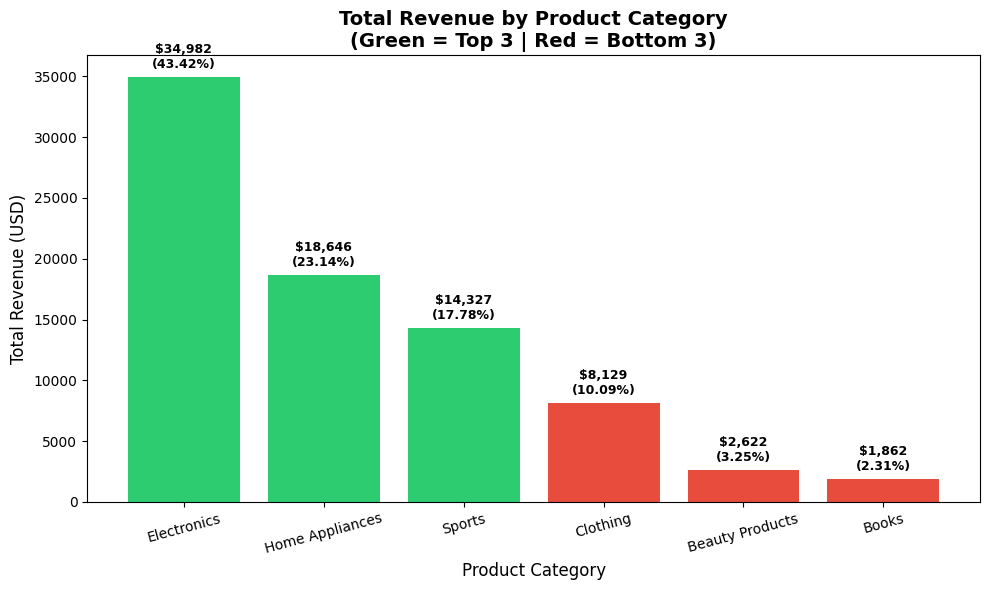

✅ Chart saved!


In [ ]:
colors = ['#2ecc71' if i < 3 else '#e74c3c' for i in range(len(category_revenue))]

plt.figure(figsize=(10, 6))
bars = plt.bar(category_revenue.index, category_revenue.values, color=colors)

# Add value labels on bars
for bar, pct in zip(bars, category_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${bar.get_height():,.0f}\n({pct}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Total Revenue by Product Category\n(Green = Top 3 | Red = Bottom 3)',
          fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_category_revenue.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [ ]:
# Average order value per region
region_avg = df.groupby('Region')['Total Revenue'].mean().round(2)

# Total orders per region
region_orders = df.groupby('Region')['Total Revenue'].count()

region_df = pd.DataFrame({
    'Avg Order Value': region_avg,
    'Total Orders': region_orders
})

print("=== REGIONAL ANALYSIS ===")
print(region_df)
print("\nHighest Avg Order Value:", region_avg.idxmax(), "-", region_avg.max())
print("Most Orders:", region_orders.idxmax(), "-", region_orders.max())

=== REGIONAL ANALYSIS ===
               Avg Order Value  Total Orders
Region                                      
Asia                    280.69            80
Europe                  265.85            80
North America           460.55            80

Highest Avg Order Value: North America - 460.55
Most Orders: Asia - 80


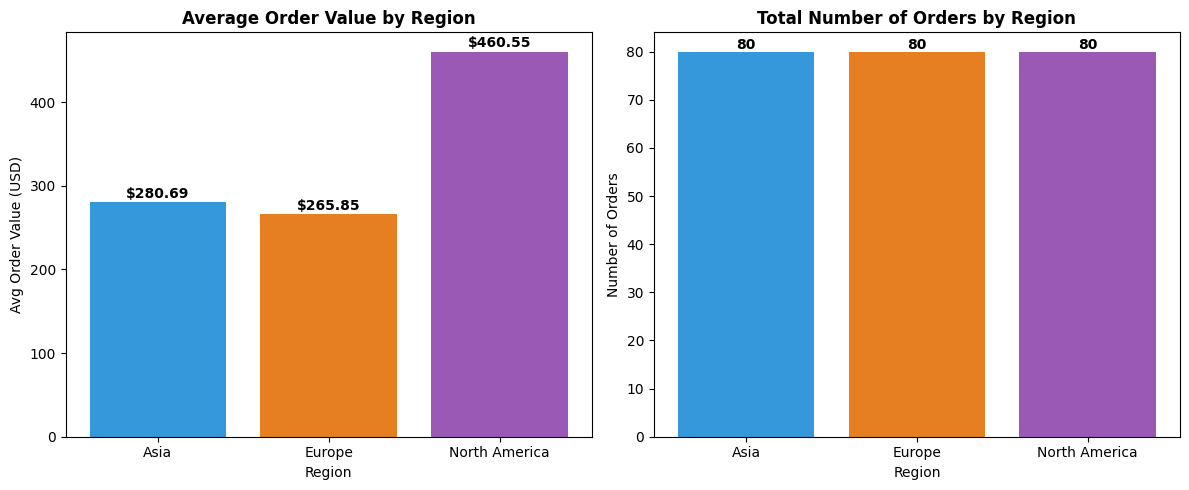

✅ Chart saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Avg Order Value
ax1.bar(region_avg.index, region_avg.values, color=['#3498db','#e67e22','#9b59b6'])
ax1.set_title('Average Order Value by Region', fontweight='bold')
ax1.set_xlabel('Region')
ax1.set_ylabel('Avg Order Value (USD)')
for i, v in enumerate(region_avg.values):
    ax1.text(i, v + 5, f'${v:.2f}', ha='center', fontweight='bold')

# Chart 2 - Total Orders
ax2.bar(region_orders.index, region_orders.values, color=['#3498db','#e67e22','#9b59b6'])
ax2.set_title('Total Number of Orders by Region', fontweight='bold')
ax2.set_xlabel('Region')
ax2.set_ylabel('Number of Orders')
for i, v in enumerate(region_orders.values):
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_regional_analysis.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [ ]:
# Monthly revenue - FIXED
monthly_raw = df.groupby('Month')['Total Revenue'].sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Fix: convert month index to integer first
monthly_raw.index = monthly_raw.index.astype(int)
monthly = monthly_raw.copy()
monthly.index = [month_names[m-1] for m in monthly_raw.index]

# Top 3 and bottom 3 months
top3 = monthly.nlargest(3).index.tolist()
bottom3 = monthly.nsmallest(3).index.tolist()

print("=== TREND ANALYSIS ===")
print(monthly)
print("\nTop 3 months:", top3)
print("Bottom 3 months:", bottom3)

=== TREND ANALYSIS ===
Jan    3817.81
Feb    1552.79
Mar    1078.76
Apr    3516.84
May    5035.95
Jun    4397.78
Jul    6715.83
Aug    2597.79
Sep    1552.82
Oct     736.85
Nov    2707.71
Dec    7879.81
Name: Total Revenue, dtype: float64

Top 3 months: ['Dec', 'Jul', 'May']
Bottom 3 months: ['Oct', 'Mar', 'Feb']


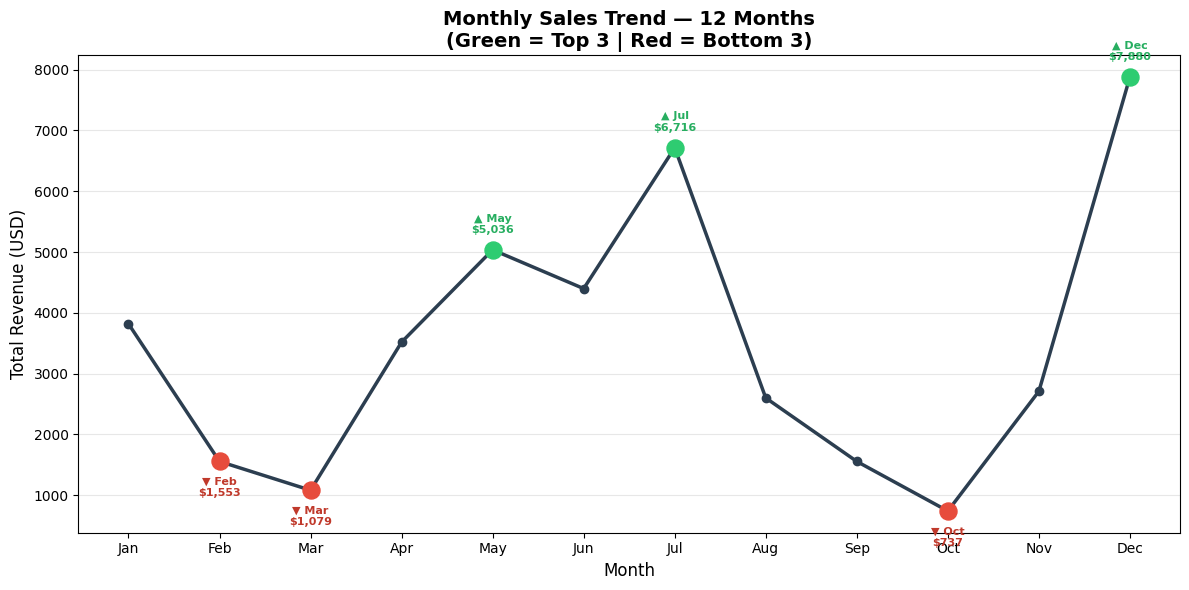

✅ Chart saved!


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly.values, marker='o',
         color='#2c3e50', linewidth=2.5, markersize=6)

# Highlight top 3 green, bottom 3 red
for month, val in monthly.items():
    if month in top3:
        plt.scatter(month, val, color='#2ecc71', s=150, zorder=5)
        plt.annotate(f'▲ {month}\n${val:,.0f}', (month, val),
                    textcoords="offset points", xytext=(0,12),
                    ha='center', fontsize=8, color='#27ae60', fontweight='bold')
    elif month in bottom3:
        plt.scatter(month, val, color='#e74c3c', s=150, zorder=5)
        plt.annotate(f'▼ {month}\n${val:,.0f}', (month, val),
                    textcoords="offset points", xytext=(0,-25),
                    ha='center', fontsize=8, color='#c0392b', fontweight='bold')

plt.title('Monthly Sales Trend — 12 Months\n(Green = Top 3 | Red = Bottom 3)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150)
plt.show()
print("✅ Chart saved!")

/tmp/ipykernel_5591/4184723349.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(category_revenue.index, rotation=15, color='white', fontsize=8)


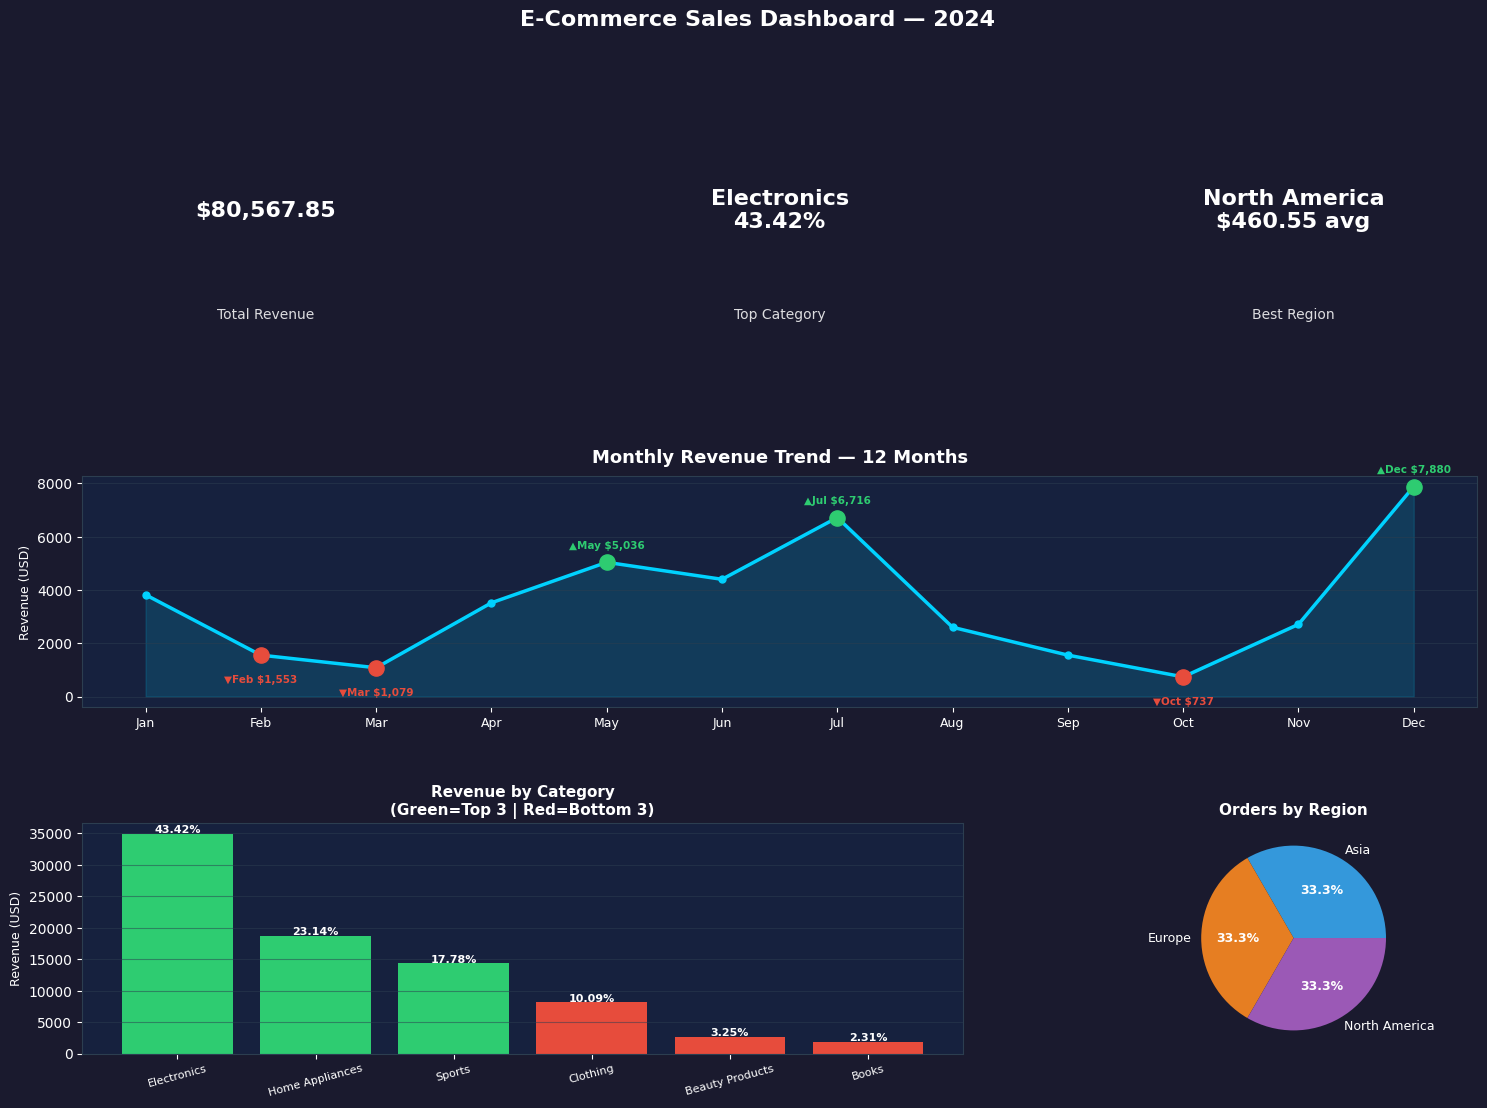

✅ Dashboard saved as dashboard_project01.png!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── KPI Cards (top row) ──────────────────────────────────────
kpis = [
    ('Total Revenue', f"${df['Total Revenue'].sum():,.2f}", '#2ecc71'),
    ('Top Category', 'Electronics\n43.42%', '#3498db'),
    ('Best Region', 'North America\n$460.55 avg', '#e67e22'),
]
for i, (title, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=16, fontweight='bold', color='white')
    ax.text(0.5, 0.2, title, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='white', alpha=0.85)
    ax.axis('off')

# ── Monthly Trend Chart ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor('#16213e')
months = monthly.index.tolist()
values = monthly.values

ax2.plot(months, values, color='#00d2ff', linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(range(len(months)), values, alpha=0.15, color='#00d2ff')

for i, (m, v) in enumerate(zip(months, values)):
    if m in top3:
        ax2.scatter(i, v, color='#2ecc71', s=120, zorder=5)
        ax2.annotate(f'▲{m} ${v:,.0f}', (i, v), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=7.5, color='#2ecc71', fontweight='bold')
    elif m in bottom3:
        ax2.scatter(i, v, color='#e74c3c', s=120, zorder=5)
        ax2.annotate(f'▼{m} ${v:,.0f}', (i, v), xytext=(0, -20),
                    textcoords='offset points', ha='center',
                    fontsize=7.5, color='#e74c3c', fontweight='bold')

ax2.set_xticks(range(len(months)))
ax2.set_xticklabels(months, color='white', fontsize=9)
ax2.set_title('Monthly Revenue Trend — 12 Months', color='white',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Revenue (USD)', color='white', fontsize=9)
ax2.tick_params(colors='white')
ax2.spines[['top','right','left','bottom']].set_color('#2c3e50')
ax2.yaxis.grid(True, color='#2c3e50', alpha=0.5)

# ── Category Bar Chart ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :2])
ax3.set_facecolor('#16213e')
cat_colors = ['#2ecc71','#2ecc71','#2ecc71','#e74c3c','#e74c3c','#e74c3c']
bars = ax3.bar(category_revenue.index, category_revenue.values, color=cat_colors)
for bar, pct in zip(bars, category_pct.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{pct}%', ha='center', fontsize=8, color='white', fontweight='bold')
ax3.set_title('Revenue by Category\n(Green=Top 3 | Red=Bottom 3)',
              color='white', fontsize=11, fontweight='bold')
ax3.set_ylabel('Revenue (USD)', color='white', fontsize=9)
ax3.tick_params(colors='white', axis='both')
ax3.set_xticklabels(category_revenue.index, rotation=15, color='white', fontsize=8)
ax3.spines[['top','right','left','bottom']].set_color('#2c3e50')
ax3.yaxis.grid(True, color='#2c3e50', alpha=0.5)

# ── Region Comparison ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2])
ax4.set_facecolor('#16213e')
region_colors = ['#3498db','#e67e22','#9b59b6']
wedges, texts, autotexts = ax4.pie(
    region_orders.values,
    labels=region_orders.index,
    autopct='%1.1f%%',
    colors=region_colors,
    textprops={'color': 'white', 'fontsize': 9}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax4.set_title('Orders by Region', color='white',
              fontsize=11, fontweight='bold')

# ── Title ─────────────────────────────────────────────────────
fig.suptitle('E-Commerce Sales Dashboard — 2024',
             color='white', fontsize=16, fontweight='bold', y=0.98)

plt.savefig('dashboard_project01.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Dashboard saved as dashboard_project01.png!")

In [ ]:
from google.colab import files
files.download('chart1_category_revenue.png')
files.download('chart2_regional_analysis.png')
files.download('chart3_monthly_trend.png')
files.download('dashboard_project01.png')
print("✅ All 4 files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All 4 files downloaded!
